# Task 1

### Imports

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Transition matrix

In [36]:
# Transition matrix
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.0000, 0.986,  0.0050, 0.004, 0.005],
    [0.0000, 0.000,  0.9920, 0.003, 0.005],
    [0.0000, 0.000,  0.0000, 0.991, 0.009],
    [0.0000, 0.000,  0.0000, 0.000, 1.000]
])

# Check that rows sum to 1
print(P.sum(axis=1))

[1. 1. 1. 1. 1.]


### Sample probabilties for transition and one woman lifetime simulation

In [37]:
def sample_next_state(probabilities, rng):
    """
    Input:
        probabilities: array of probabilities for the next state (rows of P)
        rng: random number generator
    Output:         next state (1 to 5)

    Direct method for sampling from a discrete distribution.
    States are numbered 1, ..., 5.
    """
    u = rng.random()
    cumulative = np.cumsum(probabilities) # cumulative distribution function
    return np.searchsorted(cumulative, u) + 1 # find the first index where cumulative exceeds u, +1 for 1-based state numbering


def simulate_one_woman(P, rng, check_month=60):
    """
    Simulate one woman from state 1 until death.
    Outputs:
        lifetime: number of months until death
        recurrence: whether any recurrence (local or distant) ever occurred
        local_recurrence: whether local recurrence ever occurred
        state_at_check: state at the validation month
    """
    state = 1
    lifetime = 0
    recurrence = False         # any cancer recurrence: local or distant
    local_recurrence = False   # local recurrence specifically
    state_at_check = None

    while state != 5:
        # Save state at validation month
        if lifetime == check_month:
            state_at_check = state

        # Move one month forward
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

        if state in [2, 3, 4]:
            recurrence = True

        if state in [2, 4]:
            local_recurrence = True

    # If death happened before the validation month, state remains 5
    if state_at_check is None:
        state_at_check = 5

    return lifetime,recurrence, local_recurrence, state_at_check

### Simulation settings

In [38]:
n = 1000 # number of women
seed = 1
check_month = 60   # for validation, e.g. after 5 years

rng = np.random.default_rng(seed) # we use system random number generator

lifetimes = np.zeros(n, dtype=int) # to store lifetimes of all women
recurrence = np.zeros(n, dtype=bool) # to store whether any recurrence occurred for each woman
local_recurrence = np.zeros(n, dtype=bool) # to store whether local recurrence occurred for each woman
states_at_check = np.zeros(n, dtype=int) # to store state at validation month for each woman

for i in range(n): # simulate one woman at a time and store results in the arrays
    lifetimes[i], recurrence[i], local_recurrence[i], states_at_check[i] = simulate_one_woman(
        P, rng, check_month=check_month
    )

### Summary of results

In [39]:
lifetime_summary = pd.DataFrame({
    "Mean lifetime (months)": [np.mean(lifetimes)],
    "Median lifetime (months)": [np.median(lifetimes)],
    "Std. dev. (months)": [np.std(lifetimes, ddof=1)],
    "Min": [np.min(lifetimes)],
    "25% quantile": [np.quantile(lifetimes, 0.25)],
    "75% quantile": [np.quantile(lifetimes, 0.75)],
    "Max": [np.max(lifetimes)]
})

lifetime_summary

,Mean lifetime (months),Median lifetime (months),Std. dev. (months),Min,25% quantile,75% quantile,Max
0,259.131,208.0,192.890224,1,117.75,354.0,1173


### Plot of simulation

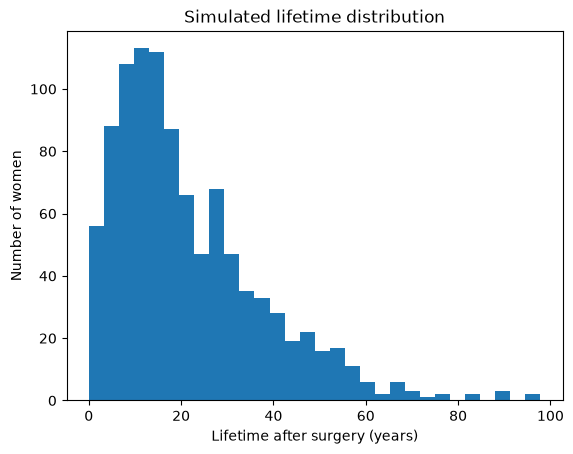

In [40]:
plt.hist(lifetimes / 12, bins=30)
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Number of women")
plt.title("Simulated lifetime distribution")
plt.show()

In [41]:
prop_any_recurrence = np.mean(recurrence)
prop_local_recurrence = np.mean(local_recurrence)
prop_local_given_recurrence = np.sum(local_recurrence) / np.sum(recurrence)

print("Proportion with any recurrence:", prop_any_recurrence)
print("Proportion with local recurrence:", prop_local_recurrence)
print("Proportion local among those with recurrence:", prop_local_given_recurrence)

Proportion with any recurrence: 0.889
Proportion with local recurrence: 0.705
Proportion local among those with recurrence: 0.7930258717660292


### Validation

In [42]:
# Analytical distribution at check_month
p0 = np.array([1, 0, 0, 0, 0])
analytical = p0 @ np.linalg.matrix_power(P, check_month)

# Simulated distribution at check_month
counts = np.bincount(states_at_check, minlength=6)[1:]
simulated = counts / n

validation_table = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Simulated": simulated,
    "Analytical": analytical,
    "Difference": simulated - analytical
})

validation_table

,State,Simulated,Analytical,Difference
0,1,0.597,0.599188,-0.002188
1,2,0.162,0.154575,0.007425
2,3,0.108,0.116549,-0.008549
3,4,0.031,0.028794,0.002206
4,5,0.102,0.100895,0.001105


# Task 2

### More imports

In [43]:
from scipy.stats import chisquare

In [44]:
def simulate_state_at_t(P, t, rng): # simulate state at month t starting from state 1
    state = 1
    
    for _ in range(t):
        state = sample_next_state(P[state - 1], rng)
    
    return state

In [45]:
n = 1000
t = 120
rng = np.random.default_rng(1)

states_120 = np.zeros(n, dtype=int)

for i in range(n):
    states_120[i] = simulate_state_at_t(P, t, rng)

### Simulated distribution

In [46]:
observed_counts = np.bincount(states_120, minlength=6)[1:]
observed_distribution = observed_counts / n

observed_counts, observed_distribution

(array([352, 179, 161,  64, 244]), array([0.352, 0.179, 0.161, 0.064, 0.244]))

### Analytical distribution

In [47]:
p0 = np.array([1, 0, 0, 0, 0])

analytical_distribution = p0 @ np.linalg.matrix_power(P, t)
expected_counts = n * analytical_distribution

expected_counts, analytical_distribution

(array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
        248.18930075]),
 array([0.35902627, 0.15895604, 0.1660869 , 0.06774149, 0.2481893 ]))

### Plot result

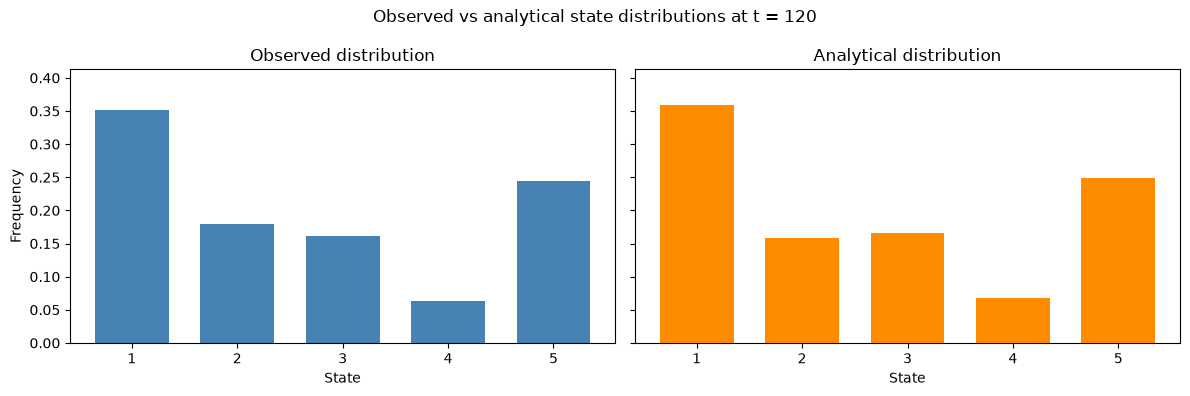

In [57]:
# Side-by-side bar charts for observed vs analytical distributions
states = np.arange(1, 6)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(states, observed_distribution, width=0.7, color="steelblue")
axes[0].set_title("Observed distribution")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(states)
axes[0].set_ylim(0, max(observed_distribution.max(), analytical_distribution.max()) * 1.15)

axes[1].bar(states, analytical_distribution, width=0.7, color="darkorange")
axes[1].set_title("Analytical distribution")
axes[1].set_xlabel("State")
axes[1].set_xticks(states)
axes[1].set_ylim(0, max(observed_distribution.max(), analytical_distribution.max()) * 1.15)

fig.suptitle("Observed vs analytical state distributions at t = 120")
fig.tight_layout()
plt.show()

### Comparrison

In [48]:
comparison = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Observed count": observed_counts,
    "Observed proportion": observed_distribution,
    "Expected proportion": analytical_distribution,
    "Expected count": expected_counts
})

comparison

,State,Observed count,Observed proportion,Expected proportion,Expected count
0,1,352,0.352,0.359026,359.026268
1,2,179,0.179,0.158956,158.956040
2,3,161,0.161,0.166087,166.086897
3,4,64,0.064,0.067741,67.741494
4,5,244,0.244,0.248189,248.189301


### Test

In [49]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 3.0981640968332864
p-value: 0.5415343741426009


The null hypothesis is that the simulated states at t = 120 follow the analytical
distribution p_120 = p_0 P^120. Since the p-value is not small, we do not reject
the null hypothesis. Therefore, the simulated distribution is consistent with the
analytical Markov chain distribution.

# Task 3

### Checking means

In [50]:
# Task 3: Phase-type distribution of lifetimes

Ps = P[:4, :4]      # transient-state transition matrix, states 1-4. Matrix of probabilities of moving between transient states (not including death)
ps = P[:4, 4]       # probabilities of dying from states 1-4

pi = np.array([1, 0, 0, 0])   # all women start in state 1
one = np.ones(4)

# Theoretical mean lifetime
theoretical_mean = pi @ np.linalg.inv(np.eye(4) - Ps) @ one

sample_mean = np.mean(lifetimes)

print("Sample mean lifetime:", sample_mean)
print("Theoretical mean lifetime:", theoretical_mean)
print("Difference:", sample_mean - theoretical_mean)

Sample mean lifetime: 259.131
Theoretical mean lifetime: 262.3716153127931
Difference: -3.2406153127931248


### Creating survival function to see theoretical vs simulated distrubution of lifetimes

In [51]:
def phase_type_survival(t, pi, Ps):
    """
    P(T > t), where T is lifetime in months.
    """
    return pi @ np.linalg.matrix_power(Ps, t) @ np.ones(Ps.shape[0])


def phase_type_bin_probability(a, b, pi, Ps):
    """
    Probability that lifetime T lies in the interval [a, b].
    If b is None, this means [a, infinity).
    """
    if b is None:
        return phase_type_survival(a - 1, pi, Ps)
    else:
        return phase_type_survival(a - 1, pi, Ps) - phase_type_survival(b, pi, Ps)

### Creatings bins to evaluate discretely

In [52]:
# Lifetime intervals in months
bins = [
    (1, 60),      # 0-5 years
    (61, 120),    # 5-10 years
    (121, 180),   # 10-15 years
    (181, 240),   # 15-20 years
    (241, 360),   # 20-30 years
    (361, 480),   # 30-40 years
    (481, None)   # more than 40 years
]

labels = [
    "0-5 years",
    "5-10 years",
    "10-15 years",
    "15-20 years",
    "20-30 years",
    "30-40 years",
    "40+ years"
]

observed_counts = []
expected_probs = []

for a, b in bins:
    if b is None:
        observed = np.sum(lifetimes >= a)
    else:
        observed = np.sum((lifetimes >= a) & (lifetimes <= b))
    
    expected_prob = phase_type_bin_probability(a, b, pi, Ps)
    
    observed_counts.append(observed)
    expected_probs.append(expected_prob)

observed_counts = np.array(observed_counts)
expected_probs = np.array(expected_probs)
expected_counts = len(lifetimes) * expected_probs

phase_type_comparison = pd.DataFrame({
    "Lifetime interval": labels,
    "Observed count": observed_counts,
    "Expected count": expected_counts,
    "Observed proportion": observed_counts / len(lifetimes),
    "Expected probability": expected_probs
})

phase_type_comparison

,Lifetime interval,Observed count,Expected count,Observed proportion,Expected probability
0,0-5 years,102,100.894713,0.102,0.100895
1,5-10 years,156,147.294588,0.156,0.147295
2,10-15 years,169,154.140231,0.169,0.154140
3,15-20 years,143,139.832617,0.143,0.139833
4,20-30 years,191,209.553027,0.191,0.209553
5,30-40 years,106,123.123801,0.106,0.123124
6,40+ years,133,125.161023,0.133,0.125161


In [53]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Minimum expected count:", expected_counts.min())

Chi-square statistic: 6.546026579749234
p-value: 0.3648749650853555
Minimum expected count: 100.8947130188207


Since the p-value is not small, we do not reject the hypothesis that the simulated lifetimes follow the theoretical phase-type distribution.

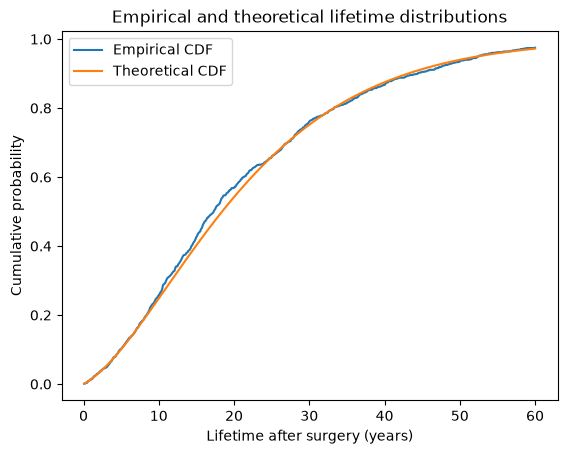

In [54]:
t_grid = np.arange(1, 721)  # first 60 years, measured in months

empirical_cdf = np.array([
    np.mean(lifetimes <= t) for t in t_grid
])

theoretical_cdf = np.array([
    1 - phase_type_survival(t, pi, Ps) for t in t_grid
])

plt.plot(t_grid / 12, empirical_cdf, label="Empirical CDF")
plt.plot(t_grid / 12, theoretical_cdf, label="Theoretical CDF")
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Cumulative probability")
plt.title("Empirical and theoretical lifetime distributions")
plt.legend()
plt.show()

### Looking at PMDF

In [55]:
max_t = max(lifetimes)

t_values = np.arange(1, max_t + 1)

theoretical_pmf = np.array([
    pi @ np.linalg.matrix_power(Ps, t - 1) @ ps
    for t in t_values
])

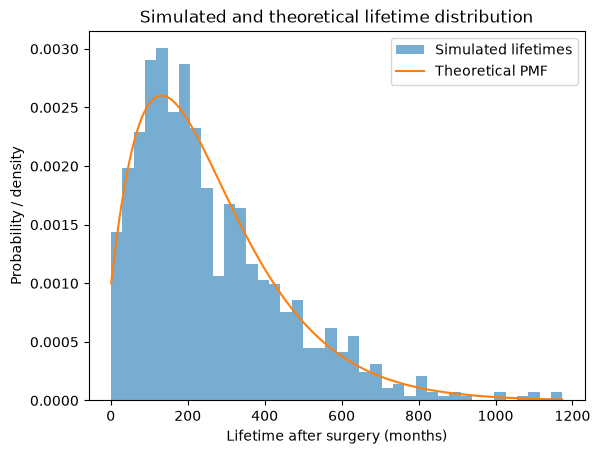

In [56]:
plt.hist(
    lifetimes,
    bins=40,
    density=True,
    alpha=0.6,
    label="Simulated lifetimes"
)

plt.plot(
    t_values,
    theoretical_pmf,
    label="Theoretical PMF"
)

plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Probability / density")
plt.title("Simulated and theoretical lifetime distribution")
plt.legend()
plt.show()

# Task 4

A={T>12 | any recurrence occurs within the first 12 months}.

In [58]:
# Task 4
from scipy.stats import t

In [59]:
def simulate_task4_candidate(P, rng, cutoff=12):
    """
    Simulate one candidate woman for Task 4.

    Accept if:
        1. She survives the first 12 months, i.e. T > 12.
        2. Cancer reappears within the first 12 months,
           either locally or distant, i.e. state 2, 3, or 4 is entered.

    Returns:
        lifetime if accepted,
        None if rejected.
    """
    state = 1
    recurrence_within_cutoff = False

    # First simulate the first 12 months
    for month in range(1, cutoff + 1):
        state = sample_next_state(P[state - 1], rng)

        # Any recurrence: local, distant, or both
        if state in [2, 3, 4]:
            recurrence_within_cutoff = True

        # If death occurs within the first 12 months, reject
        if state == 5:
            return None

    # If no recurrence occurred within the first 12 months, reject
    if not recurrence_within_cutoff:
        return None

    # Accepted: continue simulation from month 12 until death
    lifetime = cutoff

    while state != 5:
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

    return lifetime

### Simulation

In [60]:
n_accepted = 1000
cutoff = 12
seed = 4

rng = np.random.default_rng(seed)

accepted_lifetimes = []
n_simulated = 0

while len(accepted_lifetimes) < n_accepted:
    lifetime = simulate_task4_candidate(P, rng, cutoff=cutoff)
    n_simulated += 1

    if lifetime is not None:
        accepted_lifetimes.append(lifetime)

accepted_lifetimes = np.array(accepted_lifetimes)

### Results

In [61]:
mean_lifetime = np.mean(accepted_lifetimes)
std_lifetime = np.std(accepted_lifetimes, ddof=1)
se_lifetime = std_lifetime / np.sqrt(n_accepted)

ci_low, ci_high = t.interval(
    0.95,
    df=n_accepted - 1,
    loc=mean_lifetime,
    scale=se_lifetime
)

task4_summary = pd.DataFrame({
    "Accepted simulations": [n_accepted],
    "Total simulated candidates": [n_simulated],
    "Acceptance rate": [n_accepted / n_simulated],
    "Mean lifetime (months)": [mean_lifetime],
    "Mean lifetime (years)": [mean_lifetime / 12],
    "Std. dev. (months)": [std_lifetime],
    "Standard error": [se_lifetime],
    "95% CI lower (months)": [ci_low],
    "95% CI upper (months)": [ci_high],
    "Median lifetime (months)": [np.median(accepted_lifetimes)]
})

task4_summary

,Accepted simulations,Total simulated candidates,Acceptance rate,Mean lifetime (months),Mean lifetime (years),Std. dev. (months),Standard error,95% CI lower (months),95% CI upper (months),Median lifetime (months)
0,1000,12429,0.080457,173.965,14.497083,157.566567,4.982692,164.187256,183.742744,129.5


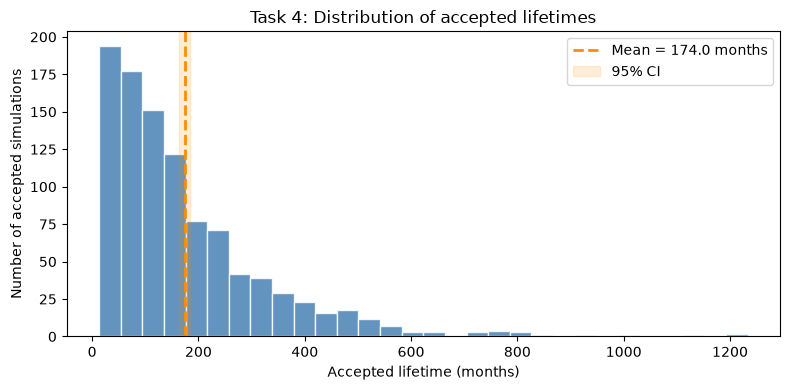

In [62]:
plt.figure(figsize=(8, 4))
plt.hist(accepted_lifetimes, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(mean_lifetime, color="darkorange", linestyle="--", linewidth=2, label=f"Mean = {mean_lifetime:.1f} months")
plt.axvspan(ci_low, ci_high, color="darkorange", alpha=0.15, label="95% CI")
plt.xlabel("Accepted lifetime (months)")
plt.ylabel("Number of accepted simulations")
plt.title("Task 4: Distribution of accepted lifetimes")
plt.legend()
plt.tight_layout()
plt.show()